# Enriched Post-Double Selection (EPDS)
### Simulation Study — Main Notebook

**Research question:** Can replacing LASSO with symbolic-regression-based basis expansion in the
Post-Double Selection framework improve causal inference under nonlinear confounding?

**Methods compared:**
| Method | Selection | Inference |
|---|---|---|
| Naive OLS | none | OLS |
| Full OLS (infeasible) | all X | OLS |
| PDS-LASSO | LASSO on raw X | OLS on union |
| DML-LASSO | LASSO nuisance | orthogonal score |
| DML-NN | NN nuisance | orthogonal score |
| EPDS | PySR basis expansion + LASSO | OLS on union |
| EPDS + Du et al. | Stein pre-screen + PySR + LASSO | OLS on union |

**DGP progression:**
DGP1 (linear) → DGP2 (quadratic) → DGP3 (interactions) → DGP4 (mixed NL)
→ DGP5 (NL + linear confounding) → DGP6 (NL + mild NL confounding)
→ DGP7 (NL + severe NL confounding)

---

## 1. Setup

In [1]:
import os, sys, pickle, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display
warnings.filterwarnings('ignore', message='Note: Setting `random_state`')

sys.path.insert(0, '.')

from dgp        import (dgp1, dgp2, dgp3, dgp4, dgp5, dgp6, dgp7,
                         DGP_REGISTRY)
from estimators import (naive_ols, full_ols, pds_lasso, dml_lasso, dml_nn,
                         epds, epds_du, ESTIMATOR_REGISTRY, EPDS_LOG)
from simulation  import run_simulation, run_all
from evaluate    import (evaluate, evaluate_all, summary_table,
                         print_summary, evaluate_recovery,
                         recovery_summary_table)
from plots       import (plot_distributions, plot_coverage, plot_rmse_heatmap,
                         plot_bias, plot_summary_panel,
                         plot_recovery_heatmap, plot_coefficient_recovery,
                         plot_n_trajectory, plot_recovery_vs_n)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

os.makedirs('../results', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# ── global simulation parameters ──
N      = 500    # sample size
P      = 50     # number of covariates
S      = 6      # true sparsity
BETA0  = 0.5    # true ATE
N_REPS = 10     # set to 500 for overnight production run

DGP_KEYS = ['dgp1','dgp2','dgp3','dgp4','dgp5','dgp6','dgp7']
EST_KEYS  = ['naive_ols','full_ols','pds_lasso',
             'dml_lasso','dml_nn','epds','epds_du']

print(f"n={N}  p={P}  s={S}  beta0={BETA0}  n_reps={N_REPS}")
print(f"DGPs:        {DGP_KEYS}")
print(f"Estimators:  {EST_KEYS}")
print("Setup complete.")

n=500  p=50  s=6  beta0=0.5  n_reps=10
DGPs:        ['dgp1', 'dgp2', 'dgp3', 'dgp4', 'dgp5', 'dgp6', 'dgp7']
Estimators:  ['naive_ols', 'full_ols', 'pds_lasso', 'dml_lasso', 'dml_nn', 'epds', 'epds_du']
Setup complete.


---
## 2. DGP Exploration

Inspect all 7 DGPs before running simulations: shapes, signal strength,
confounding structure, and the degree of nonlinearity.

In [2]:
# ── summary statistics for all DGPs ──
print(f"{'DGP':<6} {'label':<28} {'E[y]':>7} {'std(y)':>8} "
      f"{'E[d]':>7} {'std(d)':>8} {'corr(d,y)':>10}  truth_terms_y")
print("-" * 100)
for name, entry in DGP_REGISTRY.items():
    X, d, y, _ = entry['fn'](n=N, p=P, s=S, beta0=BETA0, seed=42)
    c = np.corrcoef(d, y)[0,1]
    tty = entry.get('truth_terms_y', [])
    ttd = entry.get('truth_terms_d', [])
    print(f"{name:<6} {entry['label']:<28} {y.mean():>7.3f} {y.std():>8.3f} "
          f"{d.mean():>7.3f} {d.std():>8.3f} {c:>10.3f}  y:{tty}  d:{ttd}")

DGP    label                           E[y]   std(y)    E[d]   std(d)  corr(d,y)  truth_terms_y
----------------------------------------------------------------------------------------------------
dgp1   Linear                        -0.205    8.298  -0.024    0.998      0.116  y:[]  d:[]
dgp2   Quadratic                      6.885   10.049  -0.024    0.998      0.116  y:[('sq', 0, None), ('sq', 2, None)]  d:[]
dgp3   Interactions                   0.020    8.332  -0.024    0.998      0.079  y:[('int', 0, 1), ('int', 3, 4)]  d:[]
dgp4   Mixed nonlinear                3.545   11.036  -0.024    0.998      0.025  y:[('cubic', 0, 1), ('log', 2, None), ('int', 3, 4)]  d:[]
dgp5   NL + linear conf.              3.648   11.201   0.183    2.611      0.185  y:[('cubic', 0, 1), ('log', 2, None), ('int', 3, 4)]  d:[]
dgp6   NL + mild NL conf.             3.577   11.397   0.040    2.362      0.354  y:[('cubic', 0, 1), ('log', 2, None), ('int', 3, 4)]  d:[('int', 3, 4)]
dgp7   NL + severe NL conf. 

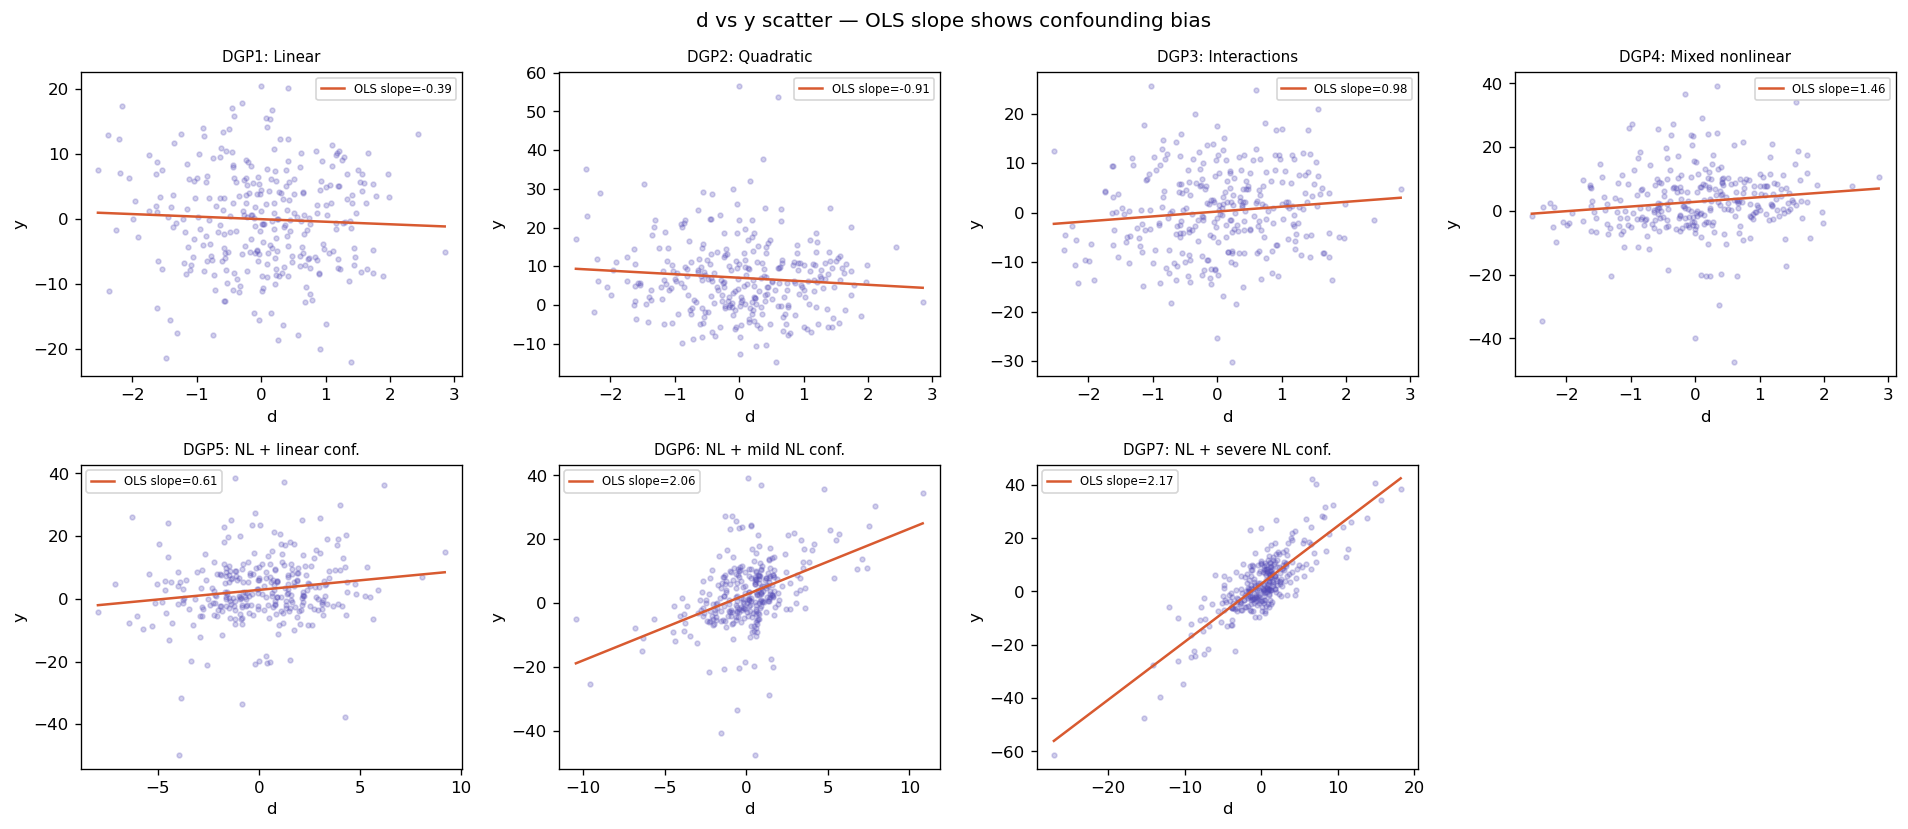

In [3]:
# ── visualise key DGPs ──
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

dgp_fns = [dgp1, dgp2, dgp3, dgp4, dgp5, dgp6, dgp7]
labels  = [DGP_REGISTRY[f'dgp{i+1}']['label'] for i in range(7)]

for i, (fn, lbl) in enumerate(zip(dgp_fns, labels)):
    ax = axes[i]
    X, d, y, _ = fn(n=300, p=P, s=S, beta0=BETA0, seed=42)
    ax.scatter(d, y, alpha=0.25, s=8, color='#534AB7')
    m, b = np.polyfit(d, y, 1)
    dr = np.linspace(d.min(), d.max(), 100)
    ax.plot(dr, m*dr+b, color='#D85A30', linewidth=1.5,
            label=f'OLS slope={m:.2f}')
    ax.set_title(f'DGP{i+1}: {lbl}', fontsize=9, fontweight='500')
    ax.set_xlabel('d'); ax.set_ylabel('y')
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
fig.suptitle('d vs y scatter — OLS slope shows confounding bias',
             fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig('../figures/dgp_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

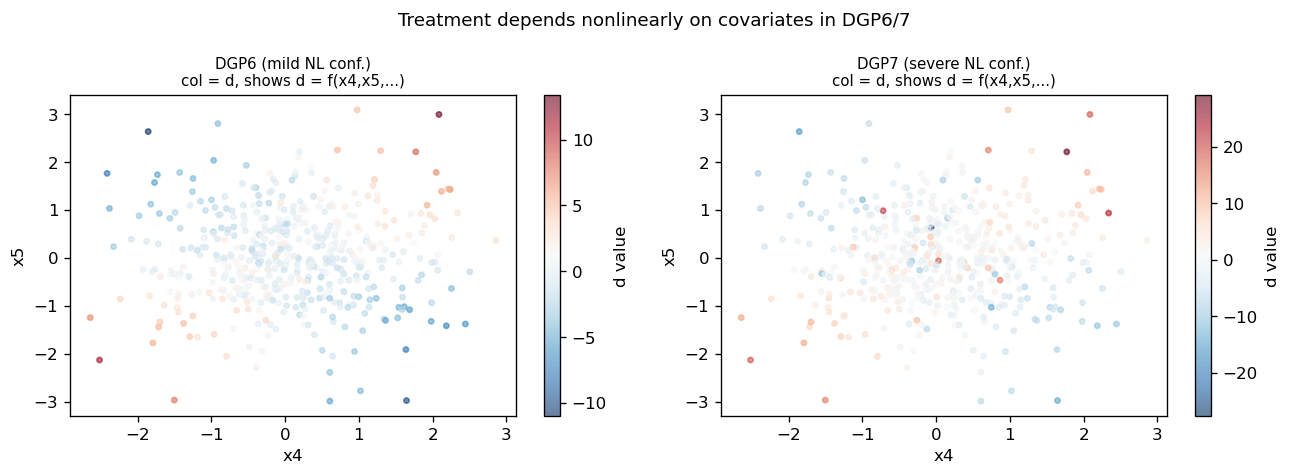

In [4]:
# ── visualise nonlinear confounding: DGP6 and DGP7 ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, fn, name in [(axes[0], dgp6, 'DGP6 (mild NL conf.)'),
                     (axes[1], dgp7, 'DGP7 (severe NL conf.)')]:
    X, d, y, _ = fn(n=500, p=P, s=S, beta0=BETA0, seed=42)
    x4, x5 = X[:, 3], X[:, 4]
    sc = ax.scatter(x4, x5, c=d, cmap='RdBu_r', s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='d value')
    ax.set_title(f'{name}\ncol = d, shows d = f(x4,x5,...)', fontsize=9)
    ax.set_xlabel('x4'); ax.set_ylabel('x5')

fig.suptitle('Treatment depends nonlinearly on covariates in DGP6/7',
             fontsize=11, fontweight='500')
plt.tight_layout()
plt.savefig('../figures/nl_confounding.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Single Estimator Walkthrough

Verify estimators produce sensible output on one (DGP, rep) before
committing to a full simulation.

In [8]:
# ── PDS-LASSO manual walkthrough on DGP5 (nonlinear + confounding) ──
from scipy.stats import norm as scipy_norm
from sklearn.linear_model import Lasso

X, d, y, beta0_true = dgp4(n=N, p=P, s=S, beta0=BETA0, seed=42)

lam = 1.1 / np.sqrt(N) * scipy_norm.ppf(1 - 0.05 / (2 * P))
print(f"Theoretical lambda: {lam:.5f}")

lasso_y = Lasso(alpha=lam, max_iter=10000).fit(X, y)
lasso_d = Lasso(alpha=lam, max_iter=10000).fit(X, d)
S_y = set(np.where(lasso_y.coef_ != 0)[0])
S_d = set(np.where(lasso_d.coef_ != 0)[0])
S_Union   = sorted(S_y | S_d)

print(f"S_y ({len(S_y)} features): {sorted(S_y)}")
print(f"S_d ({len(S_d)} features): {sorted(S_d)}")
print(f"Union ({len(S_Union)} features): {S_Union}")

# OLS on union
X_pds = np.column_stack([d, X[:, S_Union]])
X_c   = sm.add_constant(X_pds)
res   = sm.OLS(y, X_c).fit(cov_type='HC1')
print(f"\nPDS-LASSO  beta_hat={res.params[1]:.4f}  "
      f"se={res.HC1_se[1]:.4f}  true={beta0_true}")
print(f"Bias: {res.params[1] - beta0_true:.4f}  "
      f"Covers: {res.conf_int()[1,0] < beta0_true < res.conf_int()[1,1]}")

Theoretical lambda: 0.16187
S_y (38 features): [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(16), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(28), np.int64(29), np.int64(30), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(48), np.int64(49)]
S_d (0 features): []
Union (38 features): [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(16), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(28), np.int64(29), np.int64(30), np.int64(33), np.int64(34), np.int64(35), np.int64(36), n

In [6]:
# ── quick check of all non-EPDS estimators ──
X, d, y, beta0_true = dgp5(n=N, p=P, s=S, beta0=BETA0, seed=42)

print(f"DGP5 (NL + linear confounding)  true beta0={beta0_true}\n")
print(f"{'Estimator':<26} {'beta_hat':>9} {'bias':>8} {'se':>7}  covers")
print("-" * 65)

for est_key in ['naive_ols','full_ols','pds_lasso','dml_lasso','dml_nn']:
    fn  = ESTIMATOR_REGISTRY[est_key]['fn']
    res = fn(X, d, y, N, P)
    bias = res['beta_hat'] - beta0_true
    covers = res['ci_low'] < beta0_true < res['ci_high']
    print(f"{ESTIMATOR_REGISTRY[est_key]['label']:<26} "
          f"{res['beta_hat']:>9.4f} {bias:>8.4f} {res['se']:>7.4f}  {covers}")

DGP5 (NL + linear confounding)  true beta0=0.5

Estimator                   beta_hat     bias      se  covers
-----------------------------------------------------------------
Naive OLS                     0.7926   0.2926  0.2693  True
Full OLS (infeasible)         0.2006  -0.2994  0.4042  True
PDS-LASSO                     0.1952  -0.3048  0.3976  True
DML-LASSO                     0.1824  -0.3176  0.4221  True
DML-NN                        0.6209   0.1209  0.3859  True


In [7]:
# ── EPDS debug run (1 rep, debug=True, reduced iters for speed) ──
# Set debug=True to see the full Pareto frontier and extracted terms.
# Keep pysr_iters low (10-20) for interactive exploration.
X, d, y, beta0_true = dgp4(n=300, p=P, s=S, beta0=BETA0, seed=42)

EPDS_LOG.clear()
res = epds(X, d, y, 300, P, pysr_iters=20, log=True, debug=True,
           metadata={'dgp': 'dgp4', 'rep': 0})

print(f"\n  beta_hat = {res['beta_hat']:.4f}  (true = {beta0_true})")
print(f"  pre_lasso_terms_y:  {res['pre_lasso_terms_y']}")
print(f"  post_lasso_terms_y: {res['post_lasso_terms_y']}")
print(f"  term_coefs_y:       {res['term_coefs_y']}")


  EPDS CORE [epds]  n=300 p=50
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



  Pareto (Y, 8 eqs):
  idx  cplx         loss    score  equation
    0     1    108.69791   0.0000  2.8734422
    1     3     92.60365   0.0801  x1 * 4.9150586
    2     5     80.25763   0.0715  (x1 - x5) * 4.08692
    3     7     74.00857   0.0405  ((x1 - x5) * 3.9810271) - -2.504831
    4     9     71.97115   0.0140  ((x8 + 3.9811385) * (x1 - x5)) - -2.454354
    5    11     47.14751   0.2115  (((x0 * x0) * (x1 * 5.0612354)) + 0.024682041) + 3.1531436
    6    13     41.35489   0.0655  ((((x1 * x0) * x0) * 5.054034) + (x3 * x4)) + 3.1742423
    7    15     41.35408   0.0000  ((x0 * (x0 * ((x1 * 5.0612354) + 0.024682041))) + (x3 * x4))
  chosen: x0*x0*x1*5.0612354 + 0.024682041 + 3.1531436
  expanded: 5.0612354*x0**2*x1 + 3.177825641


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



  Pareto (D, 8 eqs):
  idx  cplx         loss    score  equation
    0     1      0.95787   0.0000  0.021685813
    1     3      0.92674   0.0165  x22 * 0.18495779
    2     5      0.91696   0.0053  (x41 * 0.21265282) * x0
    3     7      0.90517   0.0065  (x2 + 1.006523) * (x22 * 0.18492867)
    4     9      0.89903   0.0034  x22 * (-0.17145607 * (-1.1391438 - (x2 + x39)))
    5    11      0.88003   0.0107  x22 * (-0.17145607 * (((x21 * x35) + -1.1391438) - x2))
    6    13      0.87405   0.0034  x22 * (((((x21 * x35) + -1.2758901) - x2) - x39) * -0.139996
    7    15      0.87117   0.0017  x22 * (((((x21 * x35) - x2) + -1.0920972) - (x39 * 0.5595085
  chosen: x22*0.18495779
  expanded: 0.18495779*x22
  [Y] extracted 1 terms: [('cubic', 0, 1)]
  [D] extracted 0 terms: []
  union terms (1): ['x0^2*x1']
  X* shape: (300, 51)  (original 50 + 1 NL terms)

  LASSO step 1 -- LASSO(Y ~ X*)   S_y (26 features):
    ['x0', 'x1', 'x2', 'x3', 'x5', 'x6', 'x8', 'x9', 'x18', 'x19', 'x20', 'x21',

In [10]:
# ── EPDS + Du et al. debug run ──
X, d, y, beta0_true = dgp3(n=300, p=P, s=S, beta0=BETA0, seed=42)

EPDS_LOG.clear()
res = epds_du(X, d, y, 300, P, pysr_iters=20, log=True, debug=True,
              metadata={'dgp': 'dgp3', 'rep': 0})

print(f"\n  Du et al. selected: {res.get('du_selected', [])}")
print(f"  beta_hat = {res['beta_hat']:.4f}  (true = {beta0_true})")
print(f"  pre_lasso_terms_y:  {res['pre_lasso_terms_y']}")
print(f"  pre_lasso_terms_d:  {res['pre_lasso_terms_d']}")
print(f"  post_lasso_terms_y: {res['post_lasso_terms_y']}")
print(f"  post_lasso_terms_d: {res['post_lasso_terms_d']}")

  Du et al. selected 21 / 50 features: [0, 1, 2, 3, 4, 6, 12, 14, 17, 22, 25, 26, 33, 34, 35, 41, 42, 44, 45, 46, 47]

  EPDS CORE [epds_du]  n=300 p=50


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



  Pareto (Y, 9 eqs):
  idx  cplx         loss    score  equation
    0     1     72.32638   0.0000  x22
    1     3     47.34857   0.2118  x2 * -5.144014
    2     5     45.43396   0.0206  x2 * (x4 + -5.1751375)
    3     7     21.63769   0.3709  ((x1 * x0) - x2) * 5.345814
    4     9     21.11960   0.0121  (5.3215275 * ((x0 * x1) - x2)) - x46
    5    11     20.98629   0.0032  (((x1 * x0) - x2) * 5.3215275) - (x46 - x22)
    6    13     20.78758   0.0048  (((x1 * x0) - x2) * 5.3215275) - ((x46 - x22) * 0.66379565)
    7    14     20.78743   0.0000  (((x1 * x0) - x2) * 5.3215275) - ((x46 - x22) * sqrt(0.44706
    8    15     20.63444   0.0074  (((x1 * (x0 + 0.07324296)) - x2) * 5.3215275) - ((x46 - x22)
  chosen: (x0*x1 - x2)*5.345814
  expanded: 5.345814*x0*x1 - 5.345814*x2


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



  Pareto (D, 8 eqs):
  idx  cplx         loss    score  equation
    0     1      0.95787   0.0000  0.021579102
    1     3      0.92674   0.0165  x22 * 0.18495683
    2     5      0.91696   0.0053  (x0 * x41) * 0.21264288
    3     7      0.90517   0.0065  x22 * ((x2 + 1.0078503) * 0.18477635)
    4     9      0.89731   0.0044  ((x1 + x22) + (x22 * x2)) * 0.16768764
    5    11      0.89154   0.0032  (x22 + (x1 * ((x3 + x17) + 1.2243489))) * 0.10928095
    6    13      0.88650   0.0028  (((-0.16555455 - x1) * ((x17 + x3) + 0.9996915)) - x22) * -0
    7    15      0.87963   0.0039  ((x44 + (((x3 + 1.1097571) + x17) * x1)) - (-0.18861912 - x2
  chosen: x22*0.18495683
  expanded: 0.18495683*x22
  [Y] extracted 1 terms: [('int', 0, 1)]
  [D] extracted 0 terms: []
  union terms (1): ['x0*x1']
  X* shape: (300, 51)  (original 50 + 1 NL terms)

  LASSO step 1 -- LASSO(Y ~ X*)   S_y (16 features):
    ['x1', 'x2', 'x5', 'x9', 'x18', 'x19', 'x20', 'x21', 'x22', 'x31', 'x33', 'x35', 'x37', 'x4

---
## 4. Monte Carlo Simulation

Run all 7 DGPs × 7 estimators for N_REPS replications.

- EPDS variants always run serially (PySR is not fork-safe)
- Results saved to `../results/` as CSVs and a pickle for EPDS_LOG
- Set `N_REPS=500` for the overnight production run

In [ ]:
# ── main simulation ──
# Expected time at N_REPS=10:  ~55 min  (EPDS variants dominate)
# Expected time at N_REPS=500: ~35 hrs  (reduce DGP_KEYS to 5 if needed)

EPDS_LOG.clear()

combined = run_all(
    dgp_registry       = DGP_REGISTRY,
    estimator_registry = ESTIMATOR_REGISTRY,
    dgp_keys           = DGP_KEYS,
    estimator_keys     = EST_KEYS,
    n=N, p=P, s=S, beta0=BETA0,
    n_reps             = N_REPS,
    n_jobs             = 4,       # parallelism for non-EPDS estimators
    save_dir           = '../results',
)

print(f"\nRows in combined: {len(combined)}")
print(f"EPDS_LOG entries: {len(EPDS_LOG)}")
print(combined.groupby(['dgp','estimator'])['beta_hat'].count().to_string())

In [ ]:
# ── reload results if restarting kernel after a completed run ──
# (skip this cell if combined is already in memory)

import pickle, ast

combined = pd.read_csv('../results/all_results.csv')

# reload EPDS_LOG from pickle
with open('../results/epds_log.pkl', 'rb') as f:
    EPDS_LOG_loaded = pickle.load(f)

# re-inject into the module-level list so evaluate_recovery can use it
from estimators import EPDS_LOG
EPDS_LOG.clear()
EPDS_LOG.extend(EPDS_LOG_loaded)

# restore list/dict columns from string representation
for col in ('pre_lasso_terms_y','pre_lasso_terms_d',
            'post_lasso_terms_y','post_lasso_terms_d',
            'term_coefs_y','term_coefs_d','du_selected'):
    if col in combined.columns:
        combined[col] = combined[col].apply(
            lambda v: ast.literal_eval(v) if isinstance(v, str) and v not in ('nan','None') else None
        )

print(f"Loaded {len(combined)} rows and {len(EPDS_LOG)} EPDS_LOG entries")

---
## 5. Standard Analysis — Bias, RMSE, Coverage, Size

All methods compared across all 7 DGPs on the standard causal inference
metrics. The key result: EPDS and EPDS+Du et al. should dominate on
nonlinear DGPs (2–7) while matching PDS-LASSO on DGP1.

In [ ]:
# ── compute all metrics ──
all_metrics = evaluate_all(combined, beta0=BETA0)
print_summary(all_metrics, beta0=BETA0)

In [ ]:
# ── display formatted metric tables ──
from evaluate import summary_table
from IPython.display import display

for metric, title in [('bias',    'Bias  (should be near 0)'),
                      ('rmse',    'RMSE  (lower is better)'),
                      ('coverage','Coverage (should be near 0.95)'),
                      ('size',    'Size / rejection rate')]:
    tbl = summary_table(all_metrics, metric=metric)
    print(f"\n{title}")
    display(tbl.style.background_gradient(
        cmap='RdYlGn_r' if metric in ('bias','rmse') else 'RdYlGn',
        axis=None).format('{:.3f}'))

In [ ]:
# ── bias dot plot ──
plot_bias(all_metrics, save=True)
plt.show()

In [ ]:
# ── coverage bar chart ──
plot_coverage(all_metrics, save=True)
plt.show()

In [ ]:
# ── RMSE heatmap ──
plot_rmse_heatmap(all_metrics, save=True)
plt.show()

In [ ]:
# ── 2×2 summary panel ──
plot_summary_panel(all_metrics, save=True)
plt.show()

In [ ]:
# ── per-DGP beta_hat distribution histograms ──
for dgp_key in DGP_KEYS:
    fig = plot_distributions(combined, beta0=BETA0, dgp_key=dgp_key, save=True)
    plt.show()

---
## 6. EPDS Recovery Analysis

EPDS-specific analysis: how well does PySR discover the true nonlinear
terms, and how well does the enriched LASSO retain them?

Two stages of recovery tracked:
- **Pre-LASSO**: did PySR find the term in its chosen equation?
- **Post-LASSO**: did the term survive the enriched LASSO selection?

The gap between pre and post LASSO is attribution:
- If pre ≈ post → LASSO correctly keeps what PySR finds
- If pre > post → LASSO is the bottleneck (drops real terms)
- If pre < post → impossible by construction

In [ ]:
# ── compute recovery statistics ──
recovery_df = evaluate_recovery(EPDS_LOG, DGP_REGISTRY)

if recovery_df.empty:
    print("WARNING: recovery_df is empty. Did the simulation run with log=True?")
    print(f"EPDS_LOG has {len(EPDS_LOG)} entries.")
else:
    print(f"Recovery DataFrame: {len(recovery_df)} rows")
    print(f"Variants: {recovery_df['variant'].unique()}")
    print(f"DGPs with Y-terms: {recovery_df[recovery_df['equation']=='y']['dgp'].unique()}")
    print(f"DGPs with D-terms: {recovery_df[recovery_df['equation']=='d']['dgp'].unique()}")
    print()
    print("Y-equation recovery (post-LASSO):")
    display(recovery_summary_table(recovery_df, stage='post_lasso', equation='y'))
    print("\nD-equation recovery (post-LASSO):")
    display(recovery_summary_table(recovery_df, stage='post_lasso', equation='d'))

In [ ]:
# ── recovery heatmap: Y-equation terms ──
# Red = 0%, Yellow = 50%, Green = 100%
# Columns: (variant, pre/post-LASSO)
if not recovery_df.empty:
    plot_recovery_heatmap(recovery_df, equation='y', save=True)
    plt.show()

In [ ]:
# ── recovery heatmap: D-equation terms (DGP6 and DGP7) ──
if not recovery_df.empty:
    sub_d = recovery_df[recovery_df['equation'] == 'd']
    if not sub_d.empty:
        plot_recovery_heatmap(recovery_df, equation='d', save=True)
        plt.show()
    else:
        print("No D-equation terms in recovery_df (expected for DGPs 1-5)")

In [ ]:
# ── coefficient recovery: Y-equation ──
# Bars show mean ± std of post-LASSO OLS coefficient vs true value (dashed)
if not recovery_df.empty:
    plot_coefficient_recovery(recovery_df, equation='y', save=True)
    plt.show()

In [ ]:
# ── coefficient recovery: D-equation ──
if not recovery_df.empty:
    sub_d = recovery_df[recovery_df['equation'] == 'd']
    if not sub_d.empty:
        plot_coefficient_recovery(recovery_df, equation='d', save=True)
        plt.show()

In [ ]:
# ── tabular coefficient recovery summary ──
if not recovery_df.empty:
    coef_summary = recovery_df[
        (recovery_df['stage'] == 'post_lasso') &
        (~recovery_df['coef_bias'].isna())
    ][['dgp_label','variant','equation','term_label',
       'recovery_rate','true_coef','mean_coef','std_coef',
       'coef_bias','coef_rmse']].copy()

    coef_summary = coef_summary.round(3)
    print("Coefficient recovery summary (post-LASSO):")
    display(coef_summary.to_string(index=False))

---
## 7. N-Trajectory Analysis

How do bias and RMSE evolve as n grows from 30 to 5000?
Uses nested subsampling: one large sample per (DGP, rep), then
subsample to each N-value.

At what n does EPDS start to consistently outperform PDS-LASSO?
At what n do the nonlinear confounders get reliably recovered?

In [ ]:
# ── N-trajectory simulation ──
# Expected time: ~3 hours (10 reps × 7 DGPs × 10 N-values × 2 EPDS variants)
# Set N_TRAJ_REPS=3 for a faster sanity check (~55 min)

N_TRAJ_VALS = [30, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]
N_TRAJ_MAX  = max(N_TRAJ_VALS)
N_TRAJ_REPS = 10
TRAJ_SEEDS  = [42 + r for r in range(N_TRAJ_REPS)]

TRAJ_ESTS = {
    'naive_ols': {'fn': naive_ols, 'label': 'Naive OLS'},
    'pds_lasso': {'fn': pds_lasso, 'label': 'PDS-LASSO'},
    'dml_lasso': {'fn': dml_lasso, 'label': 'DML-LASSO'},
    'dml_nn'   : {'fn': dml_nn,    'label': 'DML-NN'},
    'epds'     : {'fn': lambda X,d,y,n,p: epds(X,d,y,n,p,log=False),
                  'label': 'EPDS'},
    'epds_du'  : {'fn': lambda X,d,y,n,p: epds_du(X,d,y,n,p,log=False),
                  'label': 'EPDS + Du et al.'},
}

import time
traj_rows = []
t0 = time.time()

for rep, seed in enumerate(TRAJ_SEEDS):
    print(f"rep {rep+1}/{N_TRAJ_REPS}  seed={seed}", end="  ")
    for dgp_key in DGP_KEYS:
        X_f, d_f, y_f, _ = DGP_REGISTRY[dgp_key]['fn'](
            n=N_TRAJ_MAX, p=P, s=S, beta0=BETA0, seed=seed)
        for n_val in N_TRAJ_VALS:
            X, d_v, y_v = X_f[:n_val], d_f[:n_val], y_f[:n_val]
            for est_key, est_entry in TRAJ_ESTS.items():
                try:
                    res = est_entry['fn'](X, d_v, y_v, n_val, P)
                    err = None
                except Exception as e:
                    res = dict(beta_hat=np.nan, se=np.nan,
                               ci_low=np.nan, ci_high=np.nan)
                    err = str(e)[:80]
                traj_rows.append(dict(
                    rep=rep, seed=seed,
                    dgp=dgp_key,
                    dgp_label=DGP_REGISTRY[dgp_key]['label'],
                    n=n_val, estimator=est_key,
                    est_label=est_entry['label'],
                    error=err, **res,
                ))
    elapsed = (time.time() - t0) / 60
    print(f"({elapsed:.1f} min)")

traj_df = pd.DataFrame(traj_rows)
traj_df.to_pickle('../results/n_trajectory.pkl')
print(f"\nSaved {len(traj_df)} rows to ../results/n_trajectory.pkl")

In [ ]:
# ── reload trajectory if restarting kernel ──
# traj_df = pd.read_pickle('../results/n_trajectory.pkl')
# print(f"Loaded {len(traj_df)} rows")

In [ ]:
# ── bias + RMSE vs n, per DGP ──
plot_n_trajectory(traj_df, beta0=BETA0, log_y=True, save=True)
plt.show()

In [ ]:
# ── term recovery rate vs n ──
plot_recovery_vs_n(traj_df, DGP_REGISTRY, save=True)
plt.show()

---
## 8. Save Final Outputs

In [ ]:
# ── save everything with a timestamped tag ──
tag = datetime.datetime.now().strftime('%d_%m_%Y_nreps') + str(N_REPS)

# metrics
all_metrics.to_csv(f'../results/{tag}_metrics.csv', index=False)

# recovery
if not recovery_df.empty:
    recovery_df.to_csv(f'../results/{tag}_recovery.csv', index=False)

# EPDS_LOG (in case run_all's auto-save was from a different session)
with open(f'../results/{tag}_epds_log.pkl', 'wb') as f:
    pickle.dump(list(EPDS_LOG), f)

print(f"Tag: {tag}")
print(f"all_metrics rows:  {len(all_metrics)}")
print(f"recovery_df rows:  {len(recovery_df) if not recovery_df.empty else 0}")
print(f"EPDS_LOG entries:  {len(EPDS_LOG)}")
print("\nFigures saved in: ../figures/")
print("\n".join(sorted(os.listdir('../figures/'))))